# Dominant Color Extraction for Image Segmentation


In [4]:
import matplotlib.pyplot as plt 
import numpy as np 
import cv2

In [5]:
img = cv2.imread('pf.jpg')
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

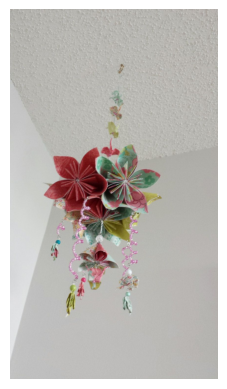

In [6]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [7]:
img.shape

(1500, 844, 3)

In [8]:
#Flatten Each channel of the Image
all_pixels = img.reshape((-1,3)) #-1 -> no of pixel
print(all_pixels.shape)

(1266000, 3)


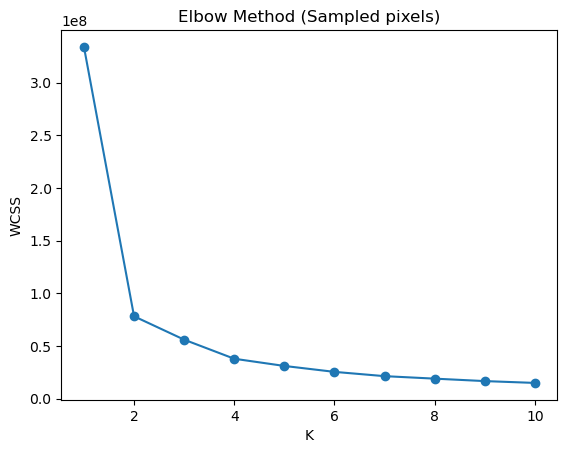

In [22]:
import numpy as np

sample_size = 100000
idx = np.random.choice(all_pixels.shape[0], sample_size, replace=False)
sample_pixels = all_pixels[idx]

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(sample_pixels)
    wcss.append(km.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method (Sampled pixels)")
plt.show()


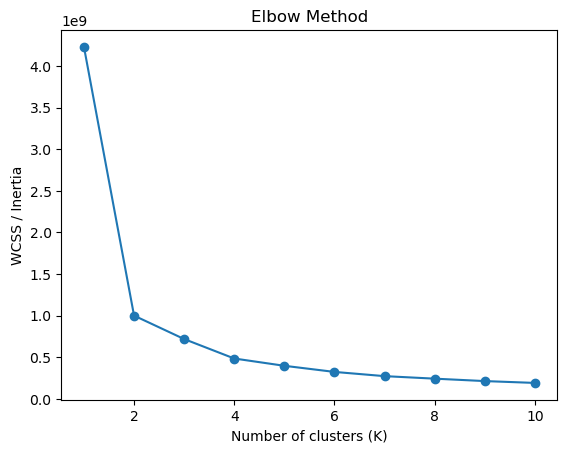

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(all_pixels)
    wcss.append(km.inertia_)   # WCSS

plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.show()


In [9]:
from sklearn.cluster import KMeans
dominant_colors = 3 

km = KMeans(n_clusters = dominant_colors)
km.fit(all_pixels)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=3)

In [11]:
centers = km.cluster_centers_
centers


array([[138.45493297, 114.72645463,  99.64108563],
       [187.26859438, 185.99725298, 182.04712761],
       [ 94.59294663,  41.77806674,  36.95608779]])

In [13]:
centers = np.array(centers, dtype= 'uint8')
print(centers)

[[138 114  99]
 [187 185 182]
 [ 94  41  36]]


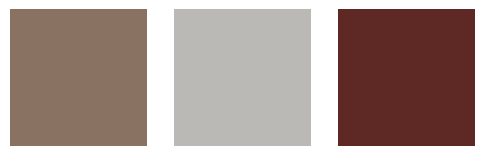

In [14]:
plt.figure(figsize=(centers.shape[0]*2,2))

i = 1

for center in centers:
    plt.subplot(1,centers.shape[0],i)
    i += 1
    na = np.zeros(shape=(100,100,3),dtype='uint8')
    na[:,:,:] = center
    plt.axis('off')
    plt.imshow(na)

plt.show()


In [15]:
new_img = np.zeros((img.shape[0]*img.shape[1],3),dtype='uint8')
print(new_img.shape)

(1266000, 3)


In [16]:
centers

array([[138, 114,  99],
       [187, 185, 182],
       [ 94,  41,  36]], dtype=uint8)

In [17]:
km.labels_

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

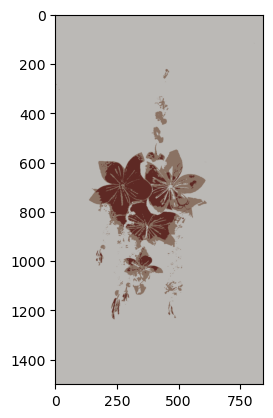

In [18]:

for ix in range(new_img.shape[0]):
    new_img[ix] = centers[km.labels_[ix]]
    
new_img = new_img.reshape((img.shape))
plt.imshow(new_img)
plt.show()